In [69]:
import pandas as pd
import numpy as np

In [70]:
df=pd.read_csv("CSVdata/Breast_Cancer_Wisconsin_Dataset.csv")


In [71]:
display(df.head(5))


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,target_name
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


In [72]:
print("Dataset Shape : ",df.shape)
print("Dataset Colums : ",df.shape[1])
print("\nDataset Info :\n",df.dtypes)
print(df['target'].value_counts())
print("Number of Mising Values : ",df.isnull().sum().sum())
print("Number of Duplicated rows : ",df.duplicated().sum())


Dataset Shape :  (569, 32)
Dataset Colums :  32

Dataset Info :
 mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity          

Text(0, 0.5, 'Count')

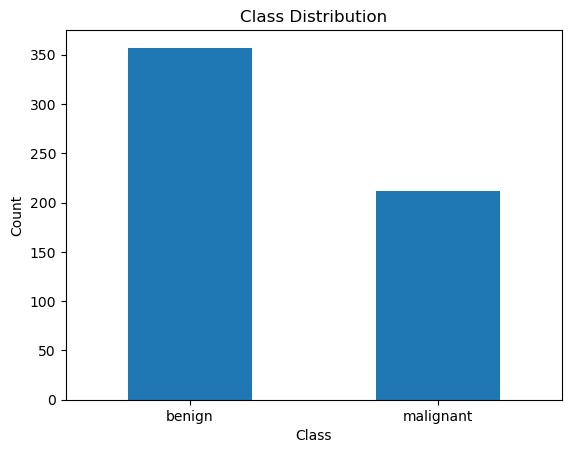

In [73]:
import matplotlib.pyplot as plt

df['target_name'].value_counts().plot(kind='bar')
plt.xticks(rotation=0)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")


In [74]:
x=df.drop(columns=['target','target_name'],axis=1)
y=df['target']

In [75]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,stratify=y)

print(len(x_train))
print(len(x_test))

426
143


In [76]:
from sklearn.preprocessing import StandardScaler

# scaled data is important for distance-based algorithms using ecludian equation  since colums with large values will cause bias and take more priority 
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

The Best K :  5


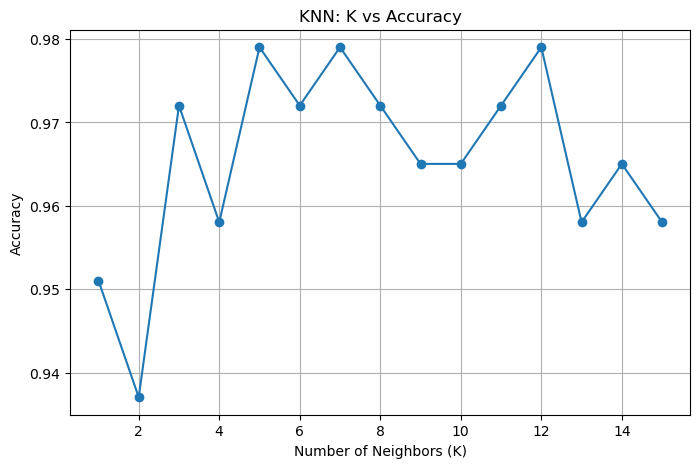

In [77]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix,ConfusionMatrixDisplay,silhouette_score)


knn_testing_accuracy=[]
for k in range(1,16):

    knn_model=KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(x_train_scaled,y_train)
    knn_y_pred=knn_model.predict(x_test_scaled)
    temp_accuracy=accuracy_score(y_test,knn_y_pred)
    knn_testing_accuracy.append(temp_accuracy)


print("The Best K : ",knn_testing_accuracy.index(max(knn_testing_accuracy))+1)

plt.figure(figsize=(8, 5))
plt.plot(range(1,16), knn_testing_accuracy, marker='o')
plt.title("KNN: K vs Accuracy")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.grid(True)




In [78]:
knn_model=KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train_scaled,y_train)


knn_accuracy = accuracy_score(y_test, knn_y_pred)
knn_precision = precision_score(y_test, knn_y_pred, average="weighted")
knn_recall = recall_score(y_test, knn_y_pred, average="weighted")
knn_f1_score = f1_score(y_test, knn_y_pred, average="weighted")
knn_confusion_matrix = confusion_matrix(y_test, knn_y_pred)
knn_classification_report = classification_report(y_test, knn_y_pred)

print(f"Accuracy : {knn_accuracy:.4f}")
print(f"Precision: {knn_precision:.4f}")
print(f"Recall   : {knn_recall:.4f}")
print(f"F1-Score : {knn_f1_score:.4f}")

print("\nClassification Report:")
print(knn_classification_report)




Accuracy : 0.9580
Precision: 0.9607
Recall   : 0.9580
F1-Score : 0.9575

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.89      0.94        53
           1       0.94      1.00      0.97        90

    accuracy                           0.96       143
   macro avg       0.97      0.94      0.95       143
weighted avg       0.96      0.96      0.96       143



In [79]:
from sklearn.tree import DecisionTreeClassifier , plot_tree

dt_testing_accuracy=[]
for d in range(1,11):
    dt_model=DecisionTreeClassifier(random_state=42,max_depth=d)
    dt_model.fit(x_train,y_train)
    dt_y_pred=dt_model.predict(x_test)
    dt_temp_accuracy=accuracy_score(y_test,dt_y_pred)
    dt_testing_accuracy.append(dt_temp_accuracy)

print("The Best Decision Tree With Max Depth =",dt_testing_accuracy.index(max(dt_testing_accuracy))+1)    


The Best Decision Tree With Max Depth = 3


Text(0.5, 1.0, 'Decision Tree Visualization')

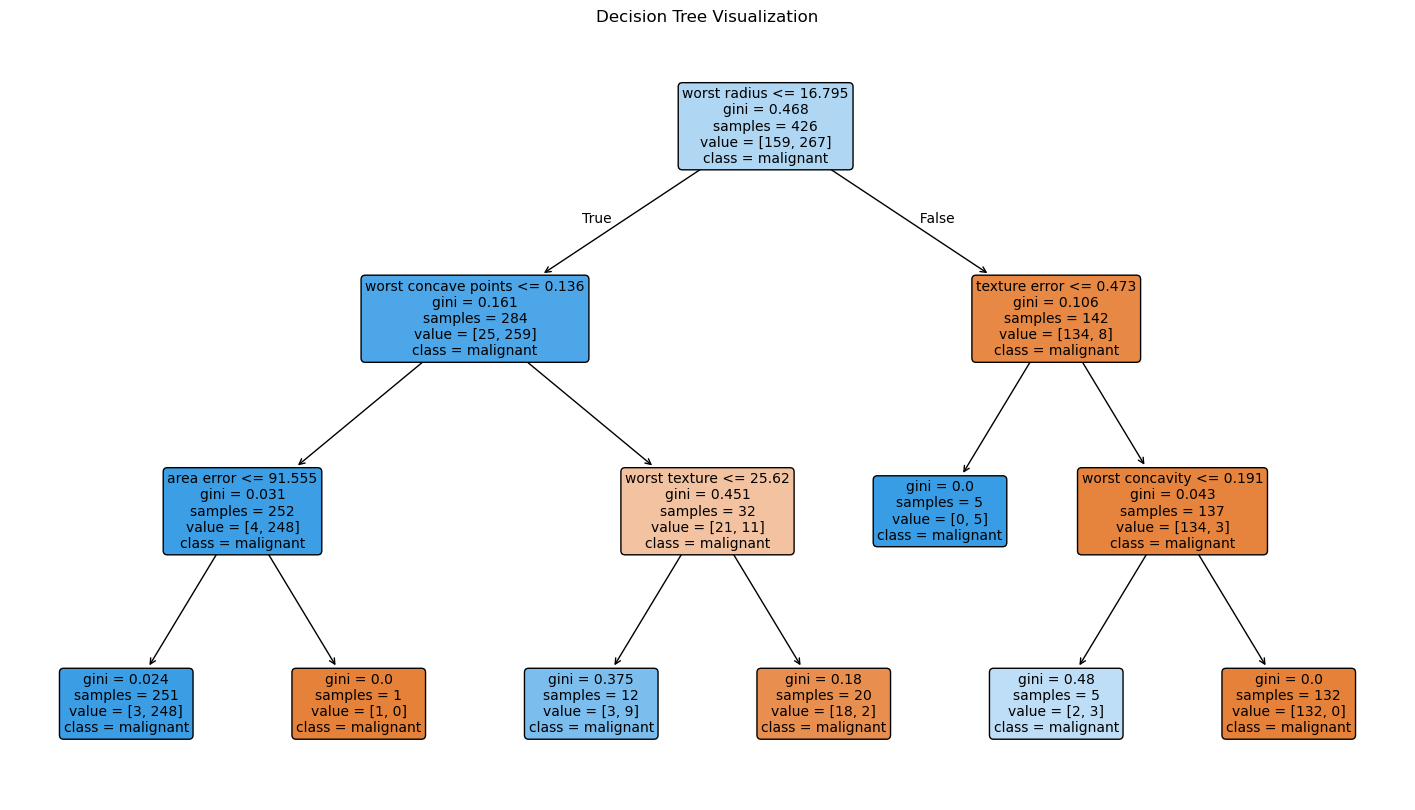

In [ ]:
dt_model=DecisionTreeClassifier(random_state=42,max_depth=3)
dt_model.fit(x_train,y_train)
dt_y_pred=dt_model.predict(x_test)
dt_accuracy=accuracy_score(y_test,dt_y_pred)
plt.figure(figsize=(18, 10))
plot_tree(dt_model,feature_names=x_train.columns,class_names=df['target_name'],filled=True,rounded=True,fontsize=10)
plt.title("Decision Tree Visualization")

In [81]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier

bagging_model=BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42), random_state=42,bootstrap=True,n_jobs=-1)

bagging_model.fit(x_train,y_train)

bagging_train_pred = bagging_model.predict(x_train)
bagging_test_pred = bagging_model.predict(x_test)


print("Training Accuracy:", accuracy_score(y_train, bagging_train_pred))
print("Testing Accuracy:", accuracy_score(y_test, bagging_test_pred))

print("\nClassification Report of Bagging :")
print(classification_report(
    y_test,
    bagging_test_pred,
   
))


Training Accuracy: 1.0
Testing Accuracy: 0.9440559440559441

Classification Report of Bagging :
              precision    recall  f1-score   support

           0       0.94      0.91      0.92        53
           1       0.95      0.97      0.96        90

    accuracy                           0.94       143
   macro avg       0.94      0.94      0.94       143
weighted avg       0.94      0.94      0.94       143



In [82]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(x_train, y_train)
rf_train_pred = random_forest_model.predict(x_train)
rf_test_pred = random_forest_model.predict(x_test)

print("Training Accuracy:", accuracy_score(y_train, rf_train_pred))
print("Testing Accuracy:", accuracy_score(y_test, rf_test_pred))


print("\nClassification Report of Random Forest :")
print(classification_report(
    y_test,
    rf_test_pred,
))

Training Accuracy: 1.0
Testing Accuracy: 0.958041958041958

Classification Report of Random Forest :
              precision    recall  f1-score   support

           0       0.96      0.92      0.94        53
           1       0.96      0.98      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143



In [83]:
def evaluate_model(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred)
    }

comparison = pd.DataFrame([
    evaluate_model("Bagging", y_test, bagging_test_pred),
    evaluate_model("Random Forest", y_test, rf_test_pred)
])

comparison.sort_values(by='F1-score',ascending=False).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1-score
0,Random Forest,0.958042,0.956522,0.977778,0.967033
1,Bagging,0.944056,0.945652,0.966667,0.956044


In [ ]:
from sklearn.cluster import KMeans


# Compute Inertia (Elbow) and Silhouette Scores
inertia = []
silhouette_scores = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(x_train_scaled)

    inertia.append(kmeans.inertia_)

    if k > 1:
        silhouette_scores.append(silhouette_score(x_train_scaled, labels))


print("Elbow Method (Inertia)")
for k, value in enumerate(inertia, start=1):
    print(f"K={k}: {value:.2f}")

print("\nSilhouette Scores")
for k, score in enumerate(silhouette_scores, start=2):
    print(f"K={k}: {score:.4f}")

# Choose the best K (highest silhouette score)
best_k = silhouette_scores.index(max(silhouette_scores)) + 2
print(f"\nBest K: {best_k}")

# Final K-Means model
final_kmeans = KMeans(n_clusters=best_k, random_state=42)
clusters = final_kmeans.fit_predict(x_train_scaled)









Elbow Method (Inertia)
K=1: 12780.00
K=2: 8605.42
K=3: 7433.90
K=4: 6863.62
K=5: 6493.76
K=6: 5932.07
K=7: 5624.97
K=8: 5362.50
K=9: 5230.77
K=10: 5078.33

Silhouette Scores
K=2: 0.3504
K=3: 0.3264
K=4: 0.2718
K=5: 0.2531
K=6: 0.1632
K=7: 0.1580
K=8: 0.1396
K=9: 0.1350
K=10: 0.1297

Best K: 2


c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

Components for 95% variance: 10


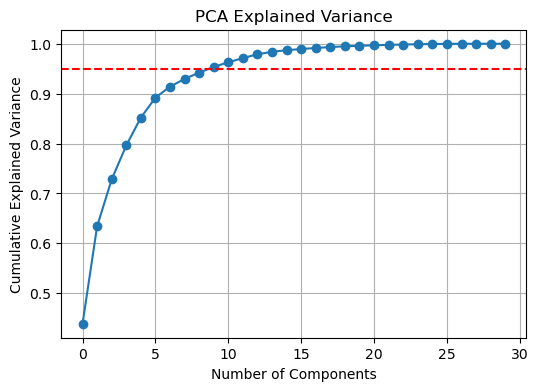

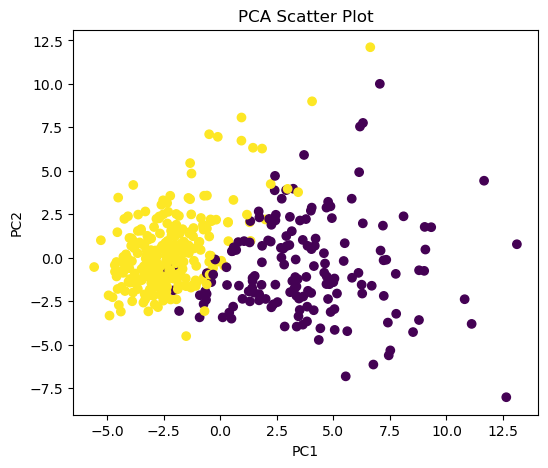

Accuracy Before PCA : 0.9790
Accuracy After PCA  : 0.9790
Training Time Before PCA : 0.011776 sec
Training Time After PCA  : 0.009328 sec


In [ ]:
from sklearn.decomposition import PCA
import time

# ---------------- PCA ----------------
pca = PCA()
pca.fit(x_train_scaled)

# Find components that explain 95% variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
best_components = np.argmax(cumulative_variance >= 0.95) + 1

print("Components for 95% variance:", best_components)

# Plot cumulative explained variance
plt.figure(figsize=(6,4))
plt.plot(cumulative_variance, marker='o')
plt.axhline(0.95, color='red', linestyle='--')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(True)
plt.show()

# Apply PCA
pca = PCA(n_components=best_components)

x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)

# 2D PCA Scatter Plot
pca_2d = PCA(n_components=2)
X_2D = pca_2d.fit_transform(x_train_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_2D[:,0], X_2D[:,1], c=y_train)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Scatter Plot")
plt.show()

#  KNN Before PCA 
start = time.perf_counter()

knn_before = KNeighborsClassifier(n_neighbors=5)
knn_before.fit(x_train_scaled, y_train)
y_pred_before = knn_before.predict(x_test_scaled)

time_before = time.perf_counter() - start
accuracy_before = accuracy_score(y_test, y_pred_before)

# KNN After PCA
start = time.perf_counter()

knn_after = KNeighborsClassifier(n_neighbors=5)
knn_after.fit(x_train_pca, y_train)
y_pred_after = knn_after.predict(x_test_pca)

time_after = time.perf_counter() - start
accuracy_after = accuracy_score(y_test, y_pred_after)


print(f"Accuracy Before PCA : {accuracy_before:.4f}")
print(f"Accuracy After PCA  : {accuracy_after:.4f}")

print(f"Training Time Before PCA : {time_before:.6f} sec")
print(f"Training Time After PCA  : {time_after:.6f} sec")

In [98]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = pd.DataFrame({
    "Model": [
        "KNN",
        "Decision Tree",
        "Random Forest",
        "Bagging",
        "KNN + PCA"
    ],
    "Accuracy": [
        accuracy_score(y_test, knn_y_pred),
        accuracy_score(y_test, dt_y_pred),
        accuracy_score(y_test, rf_test_pred),
        accuracy_score(y_test, bagging_test_pred),
        accuracy_score(y_test, y_pred_after)
    ],
    "Precision": [
        precision_score(y_test, knn_y_pred, average="weighted"),
        precision_score(y_test, dt_y_pred, average="weighted"),
        precision_score(y_test, rf_test_pred, average="weighted"),
        precision_score(y_test, bagging_test_pred, average="weighted"),
        precision_score(y_test, y_pred_after, average="weighted")
    ],
    "Recall": [
        recall_score(y_test, knn_y_pred, average="weighted"),
        recall_score(y_test, dt_y_pred, average="weighted"),
        recall_score(y_test, rf_test_pred, average="weighted"),
        recall_score(y_test, bagging_test_pred, average="weighted"),
        recall_score(y_test,y_pred_after, average="weighted")
    ],
    "F1-Score": [
        f1_score(y_test, knn_y_pred, average="weighted"),
        f1_score(y_test, dt_y_pred, average="weighted"),
        f1_score(y_test, rf_test_pred, average="weighted"),
        f1_score(y_test, bagging_test_pred, average="weighted"),
        f1_score(y_test, y_pred_after, average="weighted")
    ]
})
display(results.sort_values(by='F1-Score',ascending=False))


,Model,Accuracy,Precision,Recall,F1-Score
4,KNN + PCA,0.979021,0.979040,0.979021,0.978979
2,Random Forest,0.958042,0.958102,0.958042,0.957869
0,KNN,0.958042,0.960664,0.958042,0.957460
1,Decision Tree,0.944056,0.943993,0.944056,0.943825
3,Bagging,0.944056,0.943993,0.944056,0.943825
